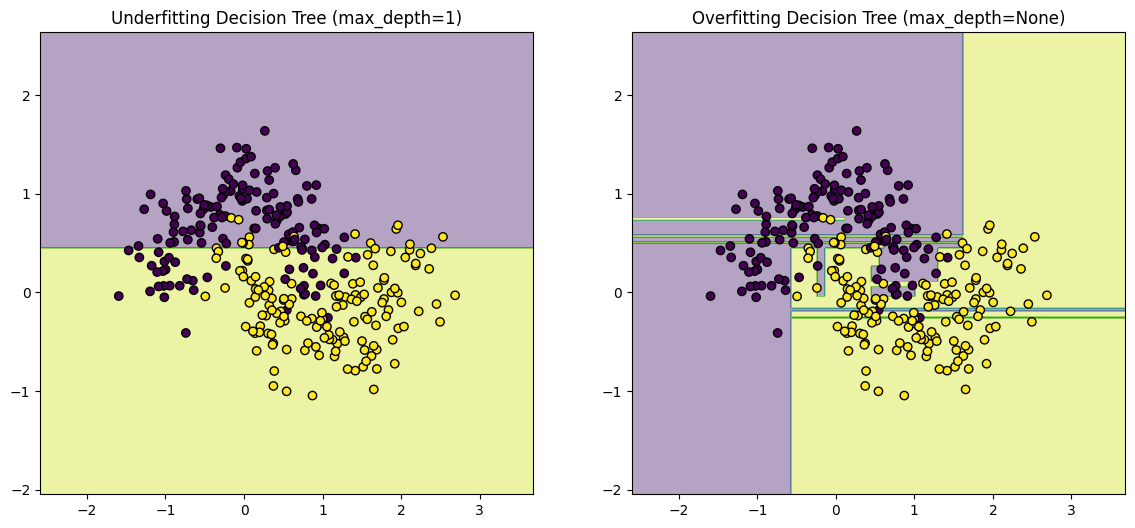

Underfitting Model
Train Accuracy: 0.8166666666666667
Test Accuracy: 0.7833333333333333

Overfitting Model
Train Accuracy: 1.0
Test Accuracy: 0.8333333333333334


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

# Generate random dataset
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create two models
underfit_model = DecisionTreeClassifier(max_depth=1)
overfit_model = DecisionTreeClassifier(max_depth=None)

# Train models
underfit_model.fit(X_train, y_train)
overfit_model.fit(X_train, y_train)

# Create meshgrid
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.01),
    np.arange(y_min, y_max, 0.01)
)

# Predictions on meshgrid
Z_under = underfit_model.predict(
    np.c_[xx.ravel(), yy.ravel()]
)
Z_under = Z_under.reshape(xx.shape)

Z_over = overfit_model.predict(
    np.c_[xx.ravel(), yy.ravel()]
)
Z_over = Z_over.reshape(xx.shape)

# Plotting
plt.figure(figsize=(14, 6))

# Underfitting plot
plt.subplot(1, 2, 1)
plt.contourf(xx, yy, Z_under, alpha=0.4)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k')
plt.title("Underfitting Decision Tree (max_depth=1)")

# Overfitting plot
plt.subplot(1, 2, 2)
plt.contourf(xx, yy, Z_over, alpha=0.4)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k')
plt.title("Overfitting Decision Tree (max_depth=None)")

plt.show()

# Accuracy scores
print("Underfitting Model")
print("Train Accuracy:", underfit_model.score(X_train, y_train))
print("Test Accuracy:", underfit_model.score(X_test, y_test))

print("\nOverfitting Model")
print("Train Accuracy:", overfit_model.score(X_train, y_train))
print("Test Accuracy:", overfit_model.score(X_test, y_test))